# SmartDs Quicklook Profiles

This notebook recreates the **line/scatter/histogram-style outputs** from the `batplotlib` `quicklook.py`, but using the current `starwinds-analysis` library and **without** Tecplot / VTK / PyVista.

Covered here:
- shell-integral line plots (mass loss, torque, open flux, axisymmetric flux fraction, energy flux)
- old-style scatter plots (`field vs radius`)
- Not covered here (placeholders included below):
- extracted Alfvén/current-sheet isosurfaces
- streamtraces / 3D streamline visualisation
- exact Tecplot 3D view state / annotations

## Setup

The sample file is a native 3D BATSRUS output from `sample_data/`.
We attach the BATSRUS + spherical recipe graphs through the library helper so derived SI quantities (`M_A`, `beta`, etc.) are available on demand.

In [9]:
import matplotlib.pyplot as plt
import numpy as np

from starwinds_analysis.data.samples import get_sample
from starwinds_analysis.smart_ds import SmartDs
from starwinds_analysis.visualisation.histograms import plot_binned_vs_radius, plot_vs_radius
from starwinds_analysis.analysis.shells import (
    integrate_shell_scalar,
    resolve_batsrus_density_si,
    resolve_batsrus_vector_xyz_si,
    resolve_field_with_scale,
    sample_spherical_shells,
)
from starwinds_analysis.recipes.spherical import spherical_vector_components

plt.rcParams["figure.dpi"] = 120
STAR_RADIUS_M = 6.957e8


In [ ]:
sample_path = get_sample("3d__var_1_n00060000.plt", echo=True)
sds = SmartDs.from_file(sample_path)
# DONE what is this function? It should not be here.
# DONE i told you not to have this defensive SHITE in teh notebook. Just do the thing. Packing it nto a function that only the notebook calls is not an improvement. It is just hiding the fact that you are doing something weird and non-standard. Just do the thing.
sds.add_batsrus_graph(body_radius_m=STAR_RADIUS_M)

sample_path


PosixPath('/Users/dagfev/Documents/starwinds/starwinds-analysis/sample_data/3d__var_1_n00060000.plt')

## Shell Radii (Quicklook-Style Integration Grid)

The old quicklook used a dense, non-uniform set of shell radii. Here we use a smaller set by default so the notebook runs quickly, but the plot shapes are the same kind of diagnostics.

In [ ]:
x_native = sorted(set(sds("X [R]")))
native_radii = [r for r in x_native if r >= 1.0]
print(f"Native unique X radii found: {len(native_radii)}")
print(f"Native radius range: [{native_radii[0]:.6g}, {native_radii[-1]:.6g}] R")

# DONE did you not understandt hat you are supposed to USE the native radii? FIx.
# Use native radii directly; stride them only to keep the notebook responsive.
stride = max(1, len(native_radii) // 16)
radii = native_radii[::stride]
if radii[-1] != native_radii[-1]:
    radii = radii + [native_radii[-1]]

# Keep this modest for a notebook. Increase to ~24x48 or more for smoother shell diagnostics.
N_POLAR = 12
N_AZIMUTH = 24

radii


Native unique X radii found: 28151
Native radius range: [1, 148] R


array([ 1.        ,  1.00100601,  1.00301194,  1.010028  ,  1.03018498,
        1.100052  ,  1.20001495,  1.33400702,  1.556692  ,  1.92875803,
        2.5485599 ,  3.58418703,  5.31026602,  8.1879158 , 12.99022961,
       21.00200081])

## Combined Shell Diagnostics (Quicklook2D Wrapper)

This single figure combines several quicklook outputs (`mass-loss`, `open-flux`, `axisymmetric-fraction`, `energy-loss`, and torque summaries).

In [ ]:
# This cell should only compute the shell diagnostics and return them.
# DONE this SHITE function is exactly what i DONT want to see in the notebook. Why? you tell me why. and add it to your instructions.
# Compute the shell profiles explicitly in the notebook and reuse one integration primitive.
rho_name, rho_scale = resolve_batsrus_density_si(sds)
(ux_name, uy_name, uz_name), u_scale = resolve_batsrus_vector_xyz_si(sds, "U")
(bx_name, by_name, bz_name), b_scale = resolve_batsrus_vector_xyz_si(sds, "B")
e_name, e_scale = resolve_field_with_scale(
    sds,
    [("E [J/m^3]", 1.0), ("E [erg/cm^3]", 1e-1)],
)

shells = sample_spherical_shells(
    sds,
    radii,
    fields=(rho_name, ux_name, uy_name, uz_name, bx_name, by_name, bz_name, e_name),
    n_polar=N_POLAR,
    n_azimuth=N_AZIMUTH,
    method="nearest",
    length_unit_to_m=STAR_RADIUS_M,
)

x = shells("X [R]")
y = shells("Y [R]")
z = shells("Z [R]")
area = shells("dA [m^2]")
height = shells("R [R]")[:, 0, 0] - 1.0

rho = rho_scale * shells(rho_name)
ux = u_scale * shells(ux_name)
uy = u_scale * shells(uy_name)
uz = u_scale * shells(uz_name)
bx = b_scale * shells(bx_name)
by = b_scale * shells(by_name)
bz = b_scale * shells(bz_name)
e = e_scale * shells(e_name)

u_r, _u_theta, u_phi = spherical_vector_components(ux, uy, uz, x, y, z)
b_r, _b_theta, b_phi = spherical_vector_components(bx, by, bz, x, y, z)

mass_loss_rate, mass_loss_coverage = integrate_shell_scalar(rho * u_r, area)
energy_flux_rate, energy_coverage = integrate_shell_scalar(e * u_r, area)
signed_flux, signed_flux_coverage = integrate_shell_scalar(b_r, area)
open_flux, open_flux_coverage = integrate_shell_scalar(np.abs(b_r), area)

b_r_axi = np.broadcast_to(np.nanmean(b_r, axis=-1, keepdims=True), b_r.shape)
axisymmetric_open_flux, axisymmetric_open_flux_coverage = integrate_shell_scalar(np.abs(b_r_axi), area)
axisymmetric_fraction = axisymmetric_open_flux / open_flux

MU0 = 4.0e-7 * np.pi
varpi_m = STAR_RADIUS_M * np.sqrt(x * x + y * y)
magnetic_torque_density = -varpi_m * b_phi * b_r / MU0
dynamic_torque_density = varpi_m * rho * u_phi * u_r
magnetic_torque, magnetic_torque_coverage = integrate_shell_scalar(magnetic_torque_density, area)
dynamic_torque, dynamic_torque_coverage = integrate_shell_scalar(dynamic_torque_density, area)
total_torque = magnetic_torque + dynamic_torque
torque_coverage = np.minimum(magnetic_torque_coverage, dynamic_torque_coverage)

height


dict_keys(['mass_loss', 'torque', 'open_flux', 'energy', 'axisymmetric_open_flux'])

## Quicklook-Style Split Line Plots (Same Diagnostics, Separate Panels)

This cell reconstructs the classic “one file per profile” style more directly, but still uses the new library-computed diagnostics.

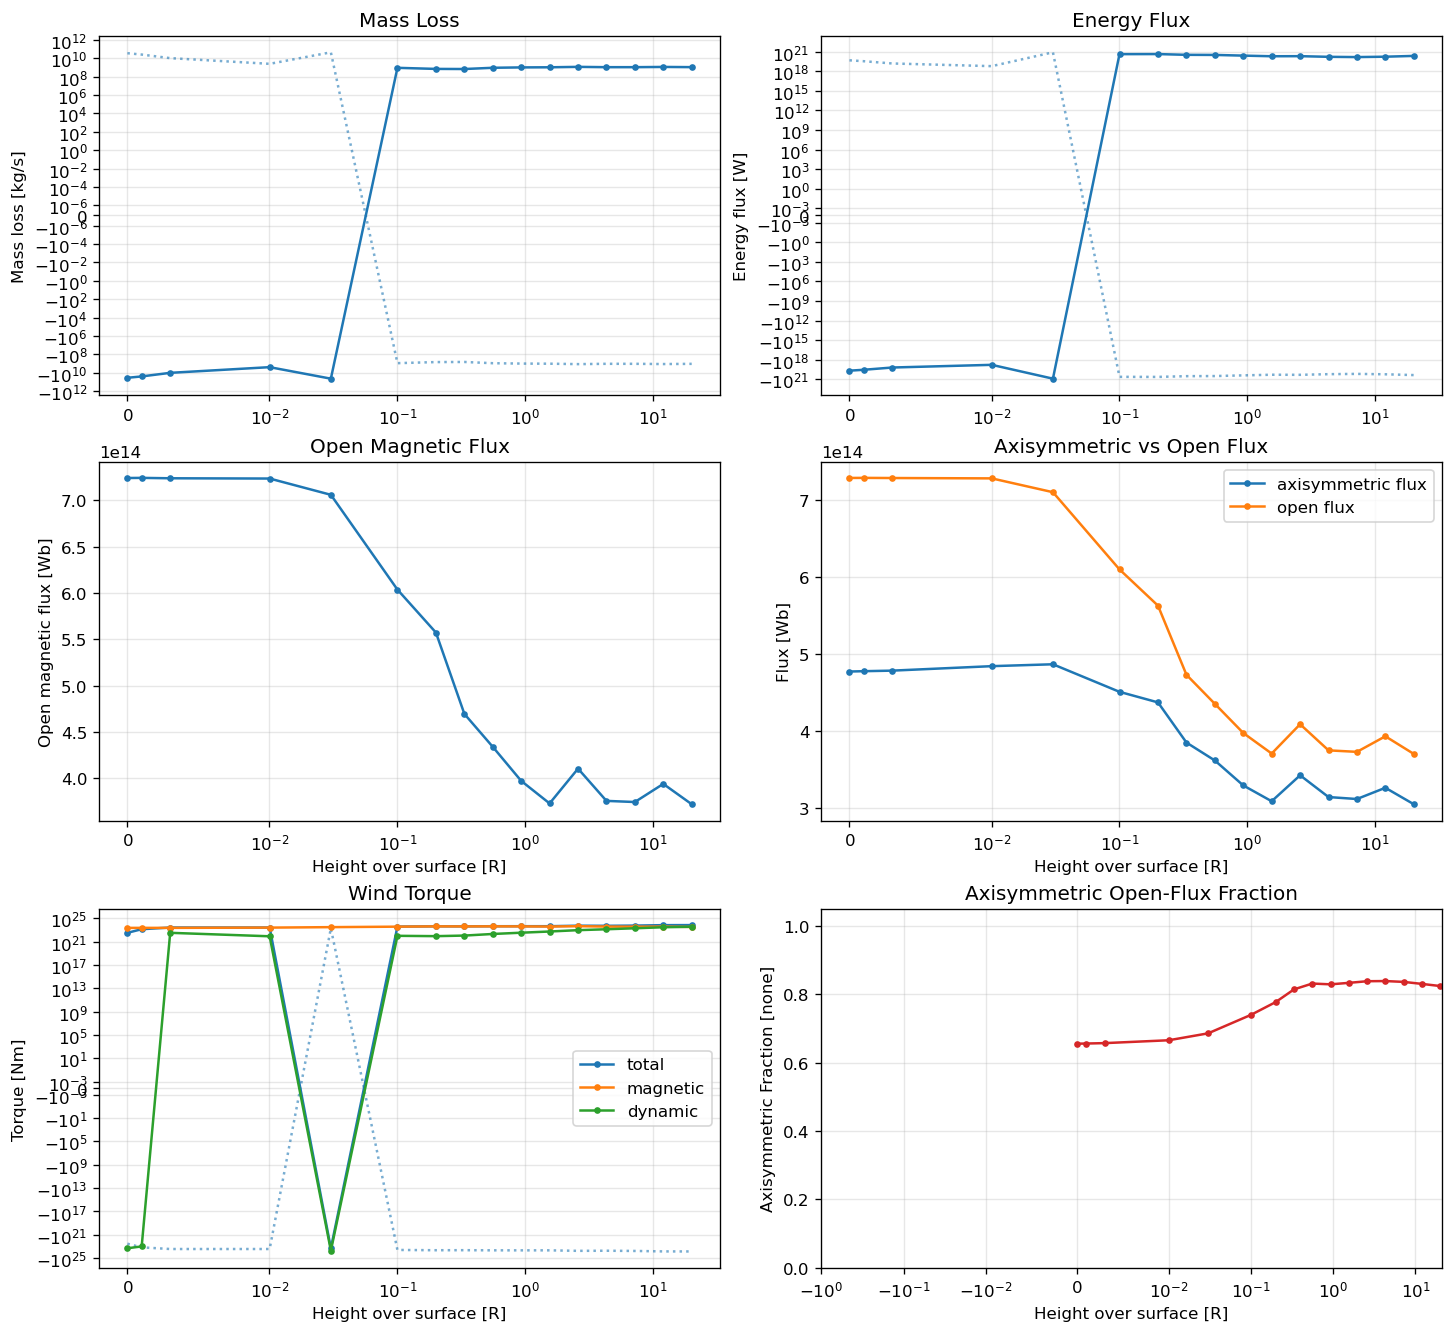

In [ ]:
# DONE what did i say about np.asarray? I said I DON"T WNT TO SEE IT in the notebook.
fig, axs = plt.subplots(3, 2, figsize=(12, 11), constrained_layout=True)

h = height
axs[0, 0].plot(h, mass_loss_rate, ".-", color="C0", label="mass loss")
axs[0, 0].plot(h, -mass_loss_rate, ":", color="C0", alpha=0.6)
axs[0, 0].set_title("Mass Loss")
axs[0, 0].set_ylabel("Mass loss [kg/s]")
axs[0, 0].set_yscale("symlog", linthresh=1e-6)

axs[0, 1].plot(h, energy_flux_rate, ".-", color="C0", label="energy flux")
axs[0, 1].plot(h, -energy_flux_rate, ":", color="C0", alpha=0.6)
axs[0, 1].set_title("Energy Flux")
axs[0, 1].set_ylabel("Energy flux [W]")
axs[0, 1].set_yscale("symlog", linthresh=1e-3)

axs[1, 0].plot(h, open_flux, ".-", color="C0", label="open flux")
axs[1, 0].set_title("Open Magnetic Flux")
axs[1, 0].set_ylabel("Open magnetic flux [Wb]")

# DONE no defensive, just do the thing. If axisymmetric_open_flux is not computed, let it error out and fix the underlying issue instead of silently plotting an empty subplot. Defensive is for automated pipelines, not for notebooks.
axs[1, 1].plot(h, axisymmetric_open_flux, ".-", label="axisymmetric flux")
axs[1, 1].plot(h, open_flux, ".-", label="open flux")
axs[1, 1].set_ylabel("Flux [Wb]")
axs[1, 1].set_title("Axisymmetric vs Open Flux")
axs[1, 1].legend(loc="best")

axs[2, 0].plot(h, total_torque, ".-", color="C0", label="total")
axs[2, 0].plot(h, -total_torque, ":", color="C0", alpha=0.6)
axs[2, 0].plot(h, magnetic_torque, ".-", color="C1", label="magnetic")
axs[2, 0].plot(h, dynamic_torque, ".-", color="C2", label="dynamic")
axs[2, 0].set_title("Wind Torque")
axs[2, 0].set_ylabel("Torque [Nm]")
axs[2, 0].set_yscale("symlog", linthresh=1e-3)
axs[2, 0].legend(loc="best")

# DONE AGAIN?
axs[2, 1].plot(h, axisymmetric_fraction, ".-", color="C3")
axs[2, 1].set_ylabel("Axisymmetric Fraction [none]")
axs[2, 1].set_ylim(0, 1.05)
axs[2, 1].set_title("Axisymmetric Open-Flux Fraction")

for ax in axs.ravel():
    ax.set_xscale("symlog", linthresh=1e-2)
    ax.grid(True, alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)

for ax in axs[1:, :].ravel():
    ax.set_xlabel("Height over surface [R]")
plt.show()


## Scatter Plots (`field` vs `radius`)

These are direct point plots (no shell averaging).

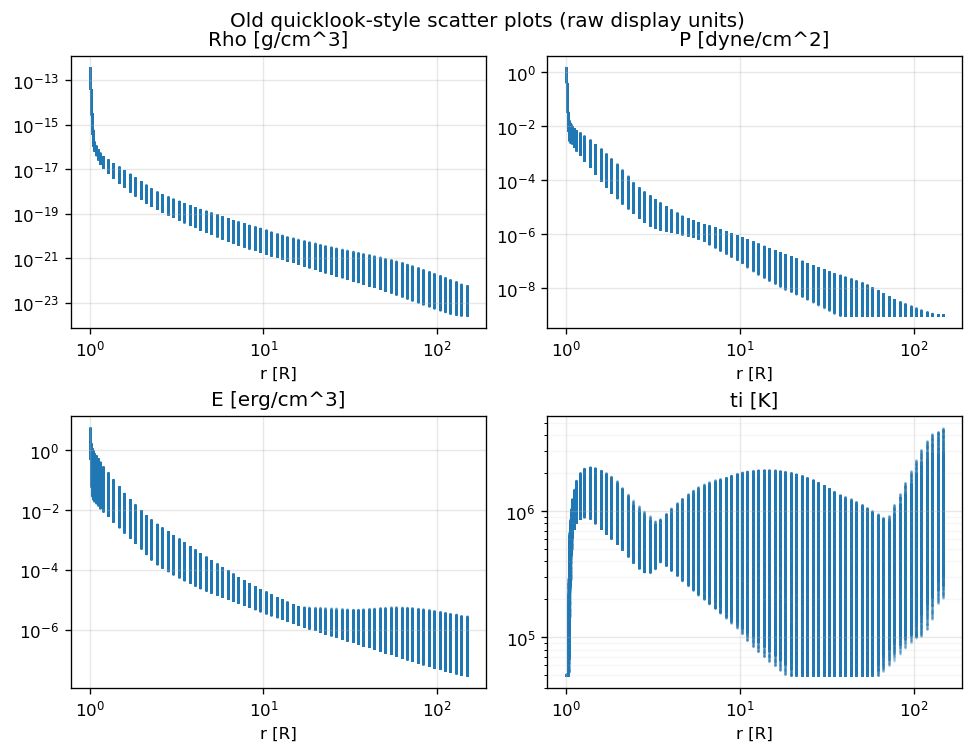

In [ ]:
# DONE just assume these fields are present.
raw_scatter_fields = (
    "Rho [g/cm^3]",
    "P [dyne/cm^2]",
    "E [erg/cm^3]",
    "ti [K]",
)

# DONE what did i say about such functions? OBFUSCATION IS BAD.
fig, axs = plt.subplots(2, 2, figsize=(8, 6), constrained_layout=True)
plot_vs_radius(sds, axs, fields=raw_scatter_fields, s=0.2, alpha=0.12)
for ax in axs.ravel():
    ax.set_xscale("symlog", linthresh=1e-2)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)
fig.suptitle("Old quicklook-style scatter plots (raw display units)", y=1.02)
plt.show()


## Binned Radial Profiles (SI-First)

This is a cleaner replacement for some of the old radial trend inspection plots, using SI or derived fields where available.

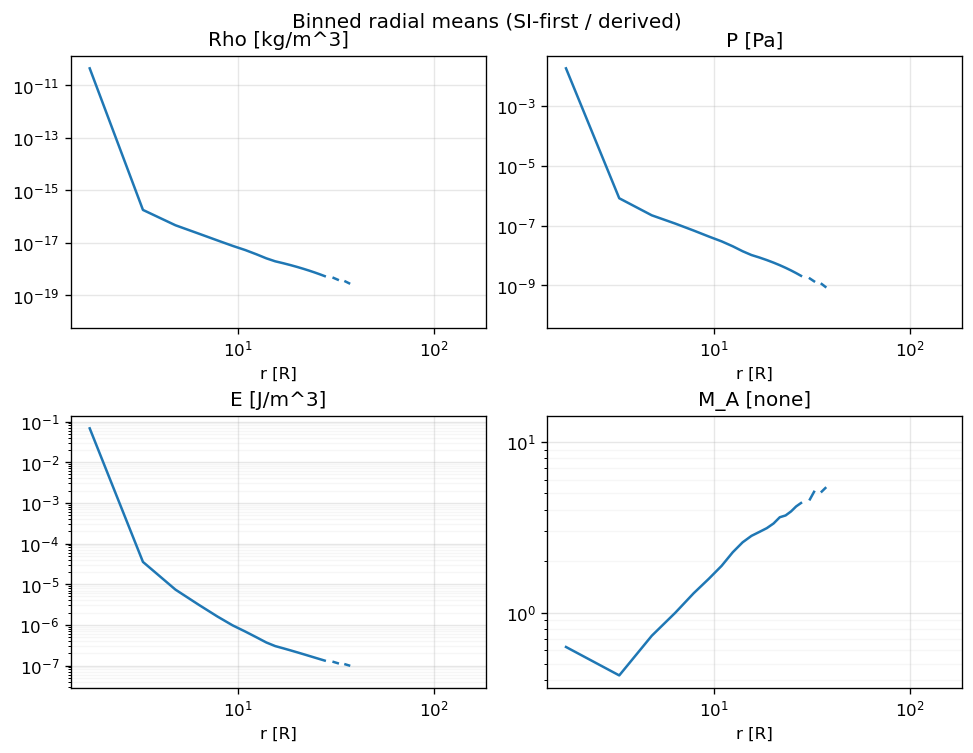

In [ ]:
# DONE Same as above look like shite. I am not even sure what the idfference is.
si_binned_fields = (
    "Rho [kg/m^3]",
    "P [Pa]",
    "E [J/m^3]",
    "M_A [none]",
)

fig, axs = plt.subplots(2, 2, figsize=(8, 6), constrained_layout=True)
plot_binned_vs_radius(sds, axs, fields=si_binned_fields, bins=96, statistic="mean")
for ax in axs.ravel():
    ax.set_xscale("symlog", linthresh=1e-2)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)
fig.suptitle("Binned radial means (SI-first / derived)", y=1.02)
plt.show()


## Placeholders: Old Quicklook Features That Still Need VTK/Tecplot-Like Geometry

These are intentionally **not** implemented in this notebook yet:

1. **Extracted Alfvén isosurface torque** (old quicklook overlaid Alfvén-surface torque markers in the torque plot).
2. **Current-sheet / Alfvén surface isosurface extraction and 3D rendering**.
3. **Streamtrace generation and visualization** (the old quicklook did Tecplot streamtraces).

The line/shell diagnostics above are still fully useful without these, and already cover the high-priority wind mass-loss and torque profiles.

In [16]:
print("Placeholder: Alfvén/current-sheet extracted surfaces and streamtraces are deferred (VTK/Tecplot geometry path).")

Placeholder: Alfvén/current-sheet extracted surfaces and streamtraces are deferred (VTK/Tecplot geometry path).
